In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# 1. Download markat data

I choose three sectorial ETF for volatility comparation, beacuase I thought it was the most relavant comparison. All USA ETS traded during the same time session.
XLK = technology -> growth-like volatility
XLE = energy -> commodity-cyclical volatility
XLU = utilities -> defensive-rate-sensitive volatility

In [2]:
assets = {
    "XLK": "Technology",
    "XLE": "Energy",
    "XLU": "Utilities"
}

start = "2018-01-01"
end = "2026-07-08"

tickers = list(assets.keys())

annualization_factor = 252

In [3]:
data = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=True,
    progress=False
)

prices=data["Close"]

prices.head()

Ticker,XLE,XLK,XLU
Date,,,
2018-01-02,25.562908,29.837343,20.004843
2018-01-03,25.945745,30.086226,19.847687
2018-01-04,26.102360,30.238304,19.682867
2018-01-05,26.091915,30.556324,19.675200
2018-01-08,26.248526,30.671543,19.859184


# 2.Calculate daily returns

In [4]:
daily_returns=prices.pct_change().dropna()

daily_returns.head()

Ticker,XLE,XLK,XLU
Date,,,
2018-01-03,0.014976,0.008341,-0.007856
2018-01-04,0.006036,0.005055,-0.008304
2018-01-05,-0.000400,0.010517,-0.000390
2018-01-08,0.006002,0.003771,0.009351
2018-01-09,-0.002519,-0.002555,-0.009844


# 3.Calculate daily volatility

In [5]:
daily_volatility=daily_returns.std()

daily_volatility

Ticker
XLE    0.019769
XLK    0.016673
XLU    0.012739
dtype: float64

# 4. Annualize volatility

In [6]:
annualized_volatility = daily_volatility * np.sqrt(annualization_factor)

annualized_volatility

Ticker
XLE    0.313818
XLK    0.264683
XLU    0.202227
dtype: float64

# 6. Create the comparison table

In [7]:
volatility_table = pd.DataFrame({
    "Sector": assets,
    "Daily Volatility": daily_volatility,
    "Annualized Volatility": annualized_volatility
})

volatility_table

,Sector,Daily Volatility,Annualized Volatility
XLE,Energy,0.019769,0.313818
XLK,Technology,0.016673,0.264683
XLU,Utilities,0.012739,0.202227


# 7. Make it readable as percentages

In [8]:
volatility_table_percent = volatility_table.copy()

volatility_table_percent["Daily Volatility"] = volatility_table_percent["Daily Volatility"] * 100
volatility_table_percent["Annualized Volatility"] = volatility_table_percent["Annualized Volatility"] * 100

volatility_table_percent

,Sector,Daily Volatility,Annualized Volatility
XLE,Energy,1.976866,31.381775
XLK,Technology,1.667348,26.468330
XLU,Utilities,1.273912,20.222726


Annalized volatiliy means: Use all daily returns from 2018-01-01 to 2026-07-08.
Calculate daily volatility.
Convert it to annualized volatility.

# View 1 — Cross-sectional volatility table

In [9]:
windows = {
    "1M Vol": 21,
    "3M Vol": 63,
    "1Y Vol": 252
}

vol_table = pd.DataFrame(index=tickers)

# Full-sample annualized volatility
vol_table["Full Sample Vol"] = daily_returns.std() * np.sqrt(annualization_factor)

# Recent rolling-window annualized volatility
for label, window in windows.items():
    vol_table[label] = daily_returns.tail(window).std() * np.sqrt(annualization_factor)

# Add sector labels
vol_table["Sector"] = pd.Series(assets)

# Reorder columns
vol_table = vol_table[
    ["Sector", "Full Sample Vol", "1M Vol", "3M Vol", "1Y Vol"]
]

# Convert to %
vol_table_percent = vol_table.copy()
vol_columns = ["Full Sample Vol", "1M Vol", "3M Vol", "1Y Vol"]

vol_table_percent[vol_columns] = vol_table_percent[vol_columns] * 100

vol_table_percent.round(2)

,Sector,Full Sample Vol,1M Vol,3M Vol,1Y Vol
XLK,Technology,26.47,44.80,32.50,24.17
XLE,Energy,31.38,23.66,25.07,20.90
XLU,Utilities,20.22,16.75,17.79,14.93


(Most recent data) Just calcultaing volatility over diff windows, it is intresting that the ranks changes, the most relevant changes we can say that is the thinner trend of the energy sector (from 31.38 overall -> 23.66 last month)

So historically, over the whole sample:

Energy was the most volatile

But recently:

Technology became the most volatile

different sectors react to different risks.

Technology → rates, earnings expectations, AI/growth repricing, market sentiment.
Energy → oil, gas, commodities, inflation, geopolitics.
Utilities → rates, regulation, defensive positioning.

So if the recent regime is dominated by technology shocks, XLK volatility rises.

If the older full sample includes big energy shocks, XLE full-sample volatility can remain higher.

# View 2 — Rolling volatility chart

In [10]:
rolling_window = 63

rolling_volatility = daily_returns.rolling(rolling_window).std() * np.sqrt(annualization_factor)

rolling_volatility.tail()

Ticker,XLE,XLK,XLU
Date,,,
2026-06-30,0.254540,0.314914,0.168976
2026-07-01,0.253970,0.312933,0.170821
2026-07-02,0.244356,0.319006,0.176317
2026-07-06,0.244037,0.319798,0.177165
2026-07-07,0.250703,0.324973,0.177932


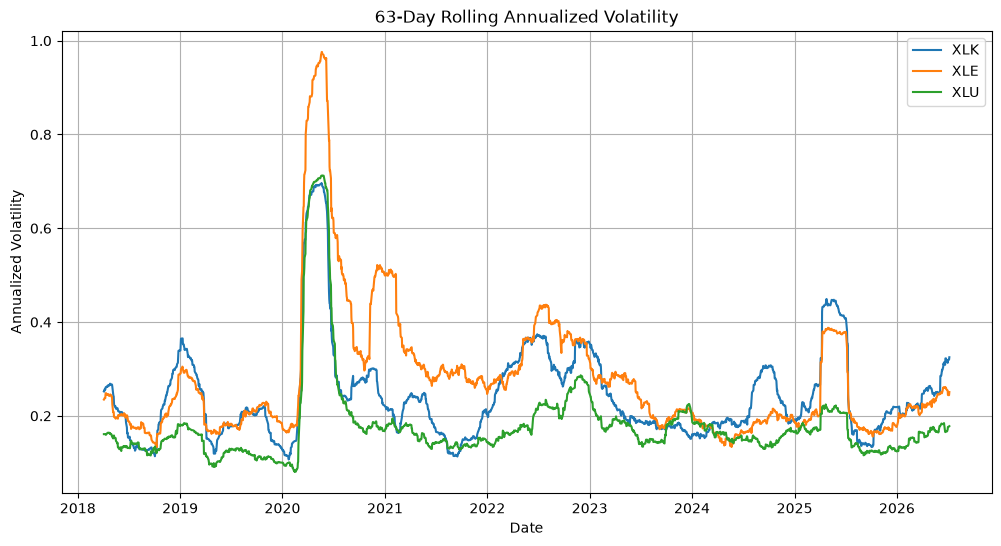

In [11]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(rolling_volatility.index, rolling_volatility[ticker], label=ticker)

plt.title("63-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

Just a volatility trough time view.